In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#Cargo los archivos .pkl
df_contactos = pd.read_pickle('data/df_contactos_clean.pkl')
df_agentes = pd.read_pickle('data/df_agentes_clean.pkl')
df_calendario = pd.read_pickle('data/df_calendario_clean.pkl')
df_campañas = pd.read_pickle('data/df_campañas_clean.pkl')

## 1. Información general de los KPIs.

### Canal de contacto más utilizado.

In [4]:
uso_por_canal = df_contactos['canal'].value_counts(normalize=True).mul(100).round(2)
uso_por_canal

canal
Teléfono    59.92
Chat        25.01
Email       15.07
Name: proportion, dtype: float64

### Área con mayor volumen de contactos

In [5]:
area_mas_contactada = df_contactos['departamento'].value_counts(normalize=True).mul(100).round(2)
area_mas_contactada

departamento
ATC                58.85
Soporte Técnico    23.52
Ventas             17.63
Name: proportion, dtype: float64

### SLA y AHT por departamentos

In [6]:
#Calculo AHT por área, en segunddos
aht_area = df_contactos.groupby(['departamento'])['duracion_segundos'].mean().round(2)
aht_area

departamento
ATC                323.27
Soporte Técnico    525.87
Ventas             222.05
Name: duracion_segundos, dtype: float64

In [7]:
#Calculo AHT por área, en minutos
aht_area_minutos = (aht_area / 60).round(2)
aht_area_minutos

departamento
ATC                5.39
Soporte Técnico    8.76
Ventas             3.70
Name: duracion_segundos, dtype: float64

In [8]:
sla_area = (df_contactos.groupby('departamento')['SLA_cumplido'].mean() * 100).round(1)
sla_area

departamento
ATC                89.9
Soporte Técnico    89.8
Ventas             90.0
Name: SLA_cumplido, dtype: float64

### Tasa de resolución

In [9]:
tasa_resolucion = (df_contactos['resuelto'].mean() * 100).round(2)
print(round(float(tasa_resolucion), 1))

92.0


### Adherencia de planificación.

In [10]:
adherencia = (df_agentes['agentes_presentes'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(adherencia), 1))

94.8


### Tasa de absentismo.

In [11]:
tasa_absentismo = (df_agentes['ausencias'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(tasa_absentismo), 1))

5.2


### Tasa vacaciones

In [12]:
tasa_vacaciones =  (df_agentes['vacaciones'].sum()/df_agentes['agentes_programados'].sum()*100).round(1)
print(round(float(tasa_vacaciones), 1))

9.7


## Conclusiones — KPIs generales

**Canal de contacto más utilizado**
Teléfono concentra el 59.9% de los contactos, muy por delante de Chat (25.0%) y Email (15.1%). Es el canal claramente dominante, con implicaciones directas para el dimensionamiento de personal: la mayor parte de la capacidad operativa debe orientarse a atención telefónica.

**Área con mayor volumen de contactos**
ATC concentra el 58.9% de los contactos, muy por encima de Soporte Técnico (23.5%) y Ventas (17.6%). Esto confirma lo descrito en el contexto de negocio: *"ATC es el departamento con mayor volumen de contactos"*.

**AHT y SLA por departamento**
- El AHT sigue el patrón esperado: **Soporte Técnico (8.76 min) > ATC (5.39 min) > Ventas (3.70 min)**, coherente con la descripción del contexto (*"Soporte Técnico presenta una duración media significativamente superior"* y *"Ventas, menor tiempo medio de atención"*).
- El SLA, en cambio, es prácticamente homogéneo entre departamentos (**ATC 89.9%, Soporte Técnico 89.8%, Ventas 90.0%**), pese a tener AHT muy distintos. Esto sugiere que el dimensionamiento de agentes está ajustado de forma diferenciada por departamento (más agentes donde el AHT es mayor) para sostener un nivel de servicio similar en los tres. Los tres están justo en el entorno del **90% objetivo** marcado en el contexto del proyecto.

**Tasa de resolución**
92.0% de los contactos quedan resueltos globalmente, un dato saludable y consistente con una operación bien gestionada.

**Adherencia a la planificación**
94.8% de adherencia global: la plantilla presente se ajusta bien a la programada.

**Absentismo**
5.2%, dentro de un rango normal-bueno para el sector (por debajo del umbral que suele considerarse problemático, 8-10%).

**Vacaciones**
9.7% de la plantilla programada de base está de vacaciones en el periodo. Esta cifra es informativa y no debe combinarse con adherencia/absentismo, ya que `agentes_programados` ya excluye a quienes tenían vacaciones planificadas.

---
En general, los indicadores muestran una operación estable y coherente con las reglas de negocio descritas en el contexto: el mayor volumen se concentra en el canal telefónico y el departamento de ATC, el AHT varía como cabía esperar entre departamentos, y el SLA se mantiene homogéneo y cercano al objetivo del 90% gracias a un dimensionamiento diferenciado. La adherencia y el absentismo indican una plantilla bien gestionada, sin señales de alerta a nivel global (aunque conviene revisar más adelante si estos promedios ocultan picos puntuales en fechas o franjas concretas).

## Análisis temporal del volumen: evolución mensual y picos de actividad.

### Total volumen 2024 vs. 2025

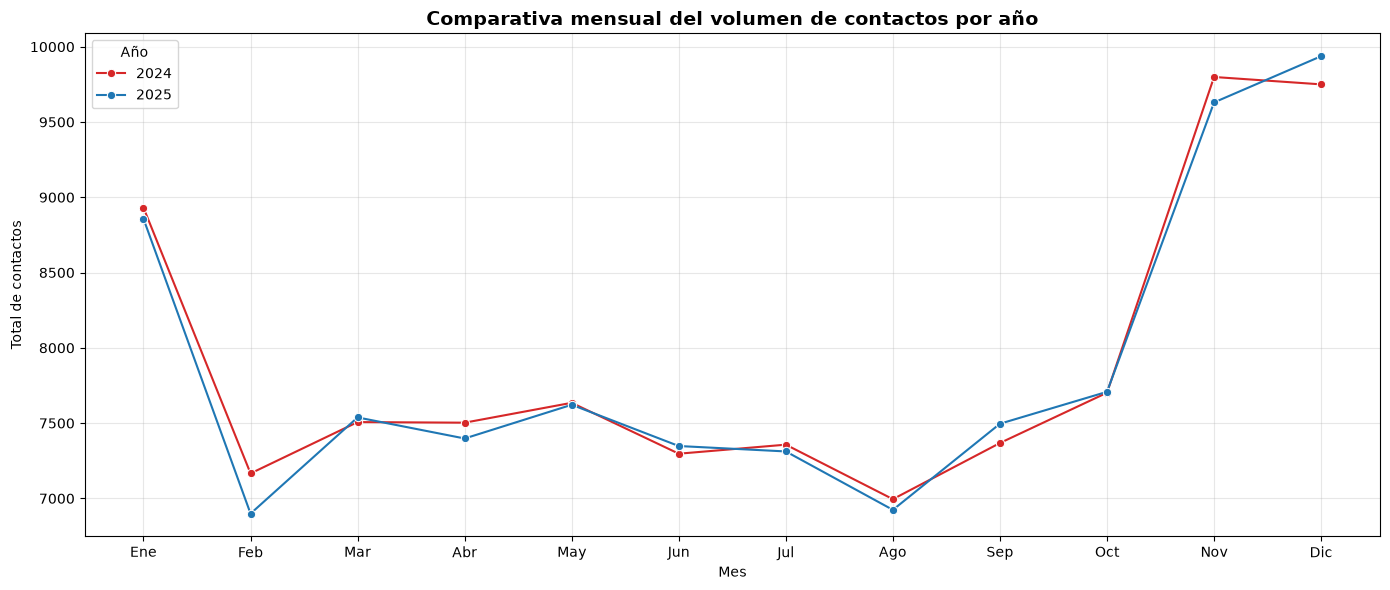

In [13]:
contactos_mes_anio = df_contactos.groupby(['anio', 'mes']).size().reset_index(name='total_contactos')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=contactos_mes_anio,
    x='mes',
    y='total_contactos',
    hue='anio',
    marker='o',
    palette=['#d62728', '#1f77b4']  # opcional, un color por año
)
plt.title('Comparativa mensual del volumen de contactos por año', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Total de contactos')
plt.xticks(ticks=range(1, 13), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Año')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Total volumen por área 2024 vs. 2025

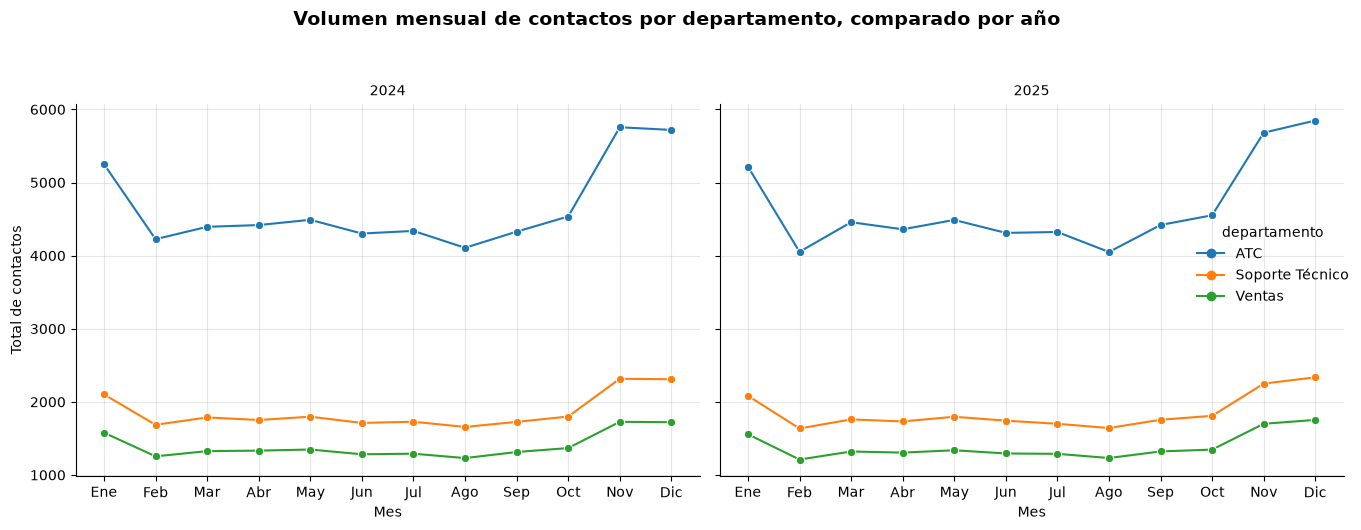

In [14]:
contactos_mes_anio_depto = df_contactos.groupby(['anio', 'mes', 'departamento']).size().reset_index(name='total_contactos')

g = sns.relplot(
    data=contactos_mes_anio_depto,
    x='mes',
    y='total_contactos',
    hue='departamento',
    col='anio',
    kind='line',
    marker='o',
    height=5,
    aspect=1.2
)

g.set_axis_labels('Mes', 'Total de contactos')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.grid(True, alpha=0.3)

g.fig.suptitle('Volumen mensual de contactos por departamento, comparado por año', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Total volumen por área y campaña 2024 vs. 2025

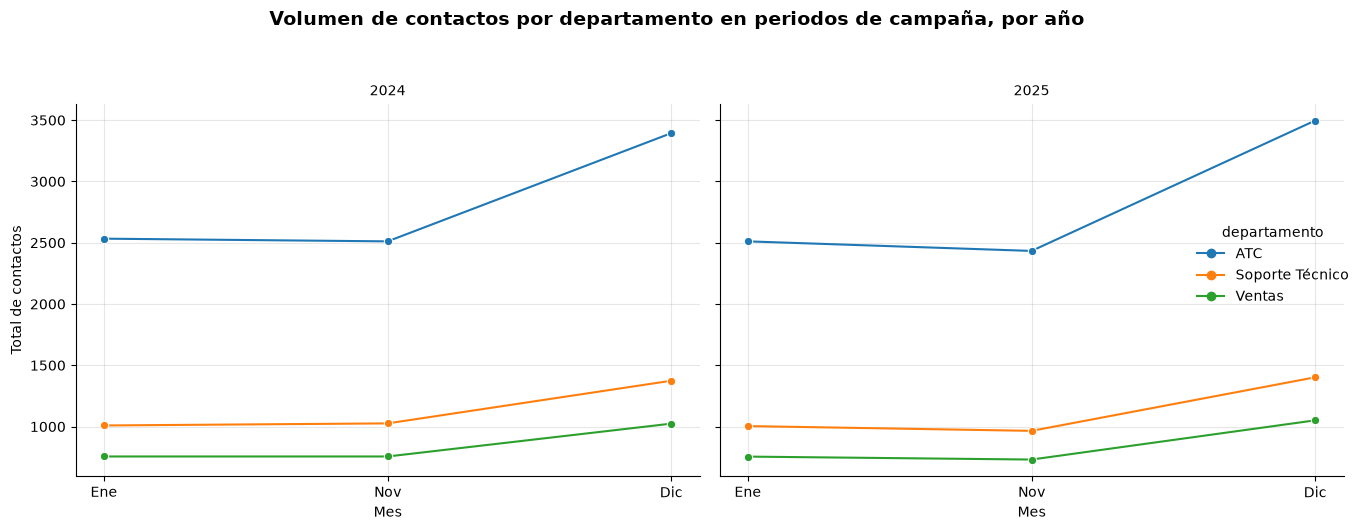

In [15]:
mes_por_campaña = df_campañas.set_index('campania')['mes_num'].to_dict()

meses_ordenados = sorted(df_campañas['mes_num'].unique())
nombres_mes = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
orden_meses = [nombres_mes[m] for m in meses_ordenados]

contactos_campaña = df_contactos[df_contactos['campania'] != 'No']

# Volumen por año, mes y departamento, solo en periodos de campaña
volumen_campania_depto = (
    contactos_campaña
    .groupby(['anio', 'mes', 'departamento'])
    .size()
    .reset_index(name='total_contactos')
)

# Orden de los meses de campaña, calculado dinámicamente desde df_campanias
nombres_mes = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

meses_ordenados = sorted(df_campañas['mes_num'].unique())
orden_meses = [nombres_mes[m] for m in meses_ordenados]

# Columna de mes como texto, para poder mapear nombres
volumen_campania_depto['mes_nombre'] = volumen_campania_depto['mes'].map(nombres_mes)

# Convertir a categórica con el orden correcto (evita huecos en el eje X)
volumen_campania_depto['mes_nombre'] = pd.Categorical(
    volumen_campania_depto['mes_nombre'],
    categories=orden_meses,
    ordered=True
)

# Gráfica
g = sns.relplot(
    data=volumen_campania_depto,
    x='mes_nombre',
    y='total_contactos',
    hue='departamento',
    col='anio',
    kind='line',
    marker='o',
    height=5,
    aspect=1.2
)

g.set_axis_labels('Mes', 'Total de contactos')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)

g.fig.suptitle('Volumen de contactos por departamento en periodos de campaña, por año', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


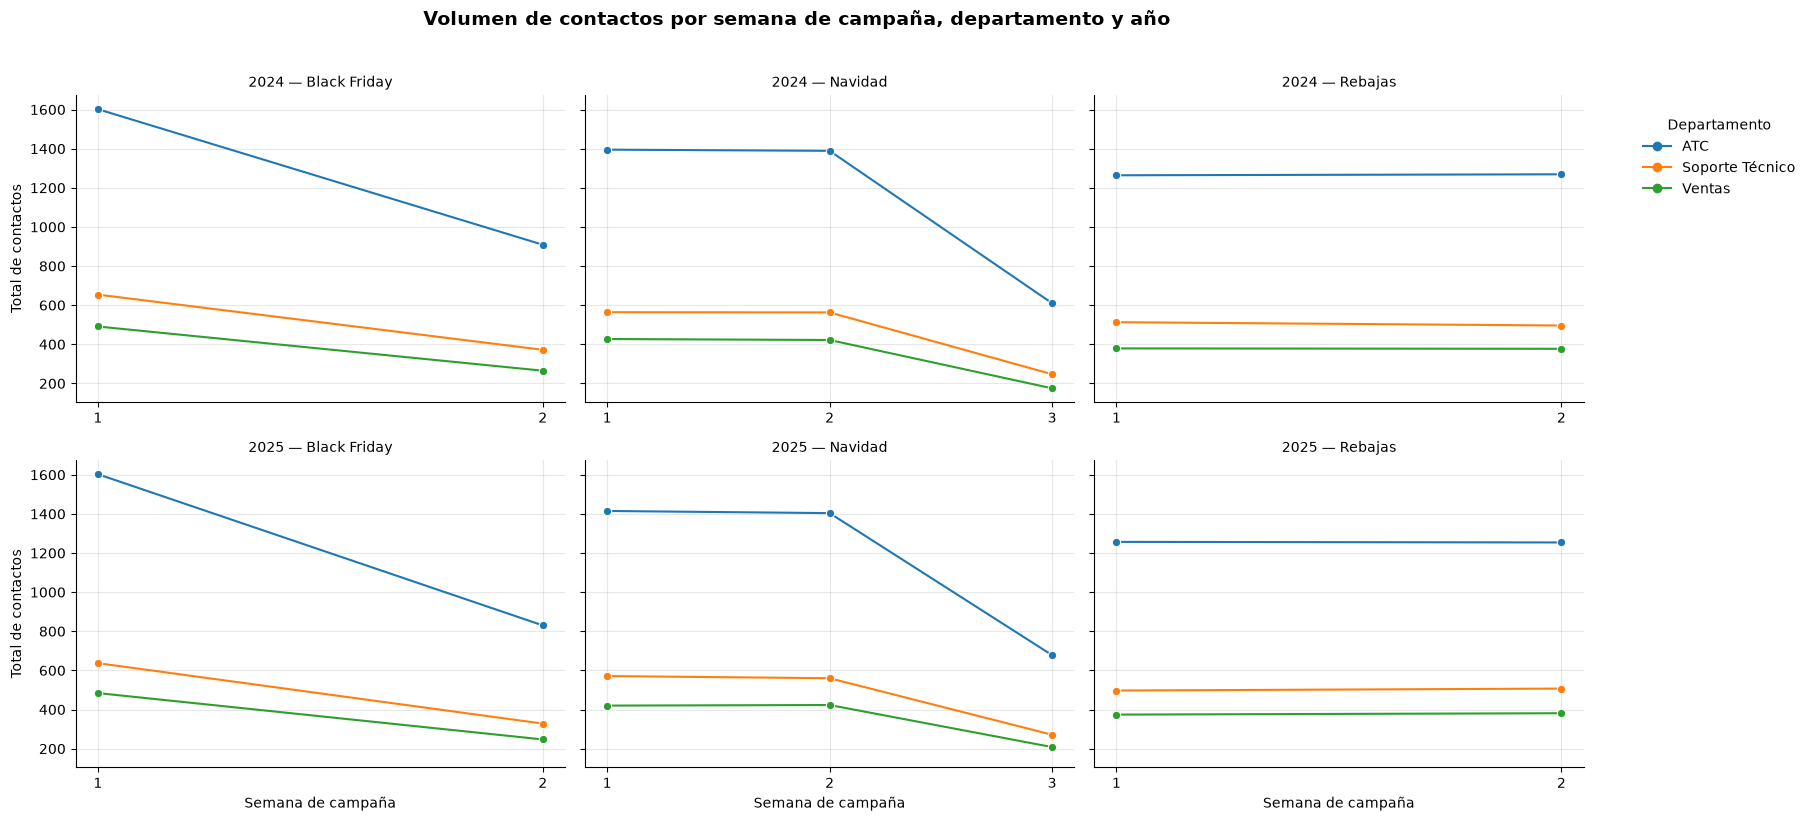

In [16]:
contactos_campania = df_contactos[df_contactos['campania'] != 'No'].copy()
contactos_campania['campania'] = contactos_campania['campania'].cat.remove_unused_categories()

# Para cada fila, calcular a qué día de la campaña corresponde
contactos_campania['dia_campania'] = (
    contactos_campania.groupby(['campania', 'anio'])['fecha']
    .transform(lambda x: (x - x.min()).dt.days)
)

# Y agrupar esos días en semanas relativas a la campaña (semana 1, 2, 3...)
contactos_campania['semana_campania'] = (contactos_campania['dia_campania'] // 7) + 1

volumen_campania_semana = (
    contactos_campania
    .groupby(['campania', 'anio', 'semana_campania', 'departamento'])
    .size()
    .reset_index(name='total_contactos')
)

g = sns.relplot(
    data=volumen_campania_semana,
    x='semana_campania',
    y='total_contactos',
    hue='departamento',
    col='campania',
    row='anio',
    kind='line',
    marker='o',
    height=4,
    aspect=1.2,
    facet_kws={'sharex': False}
)

g.set_axis_labels('Semana de campaña', 'Total de contactos')
g.set_titles('{row_name} — {col_name}')
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # fuerza números enteros en el eje

sns.move_legend(g, loc='upper left', bbox_to_anchor=(1.02, 0.9), title='Departamento')

g.fig.suptitle('Volumen de contactos por semana de campaña, departamento y año', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Total volumen por canal y campaña 2024 vs. 2025

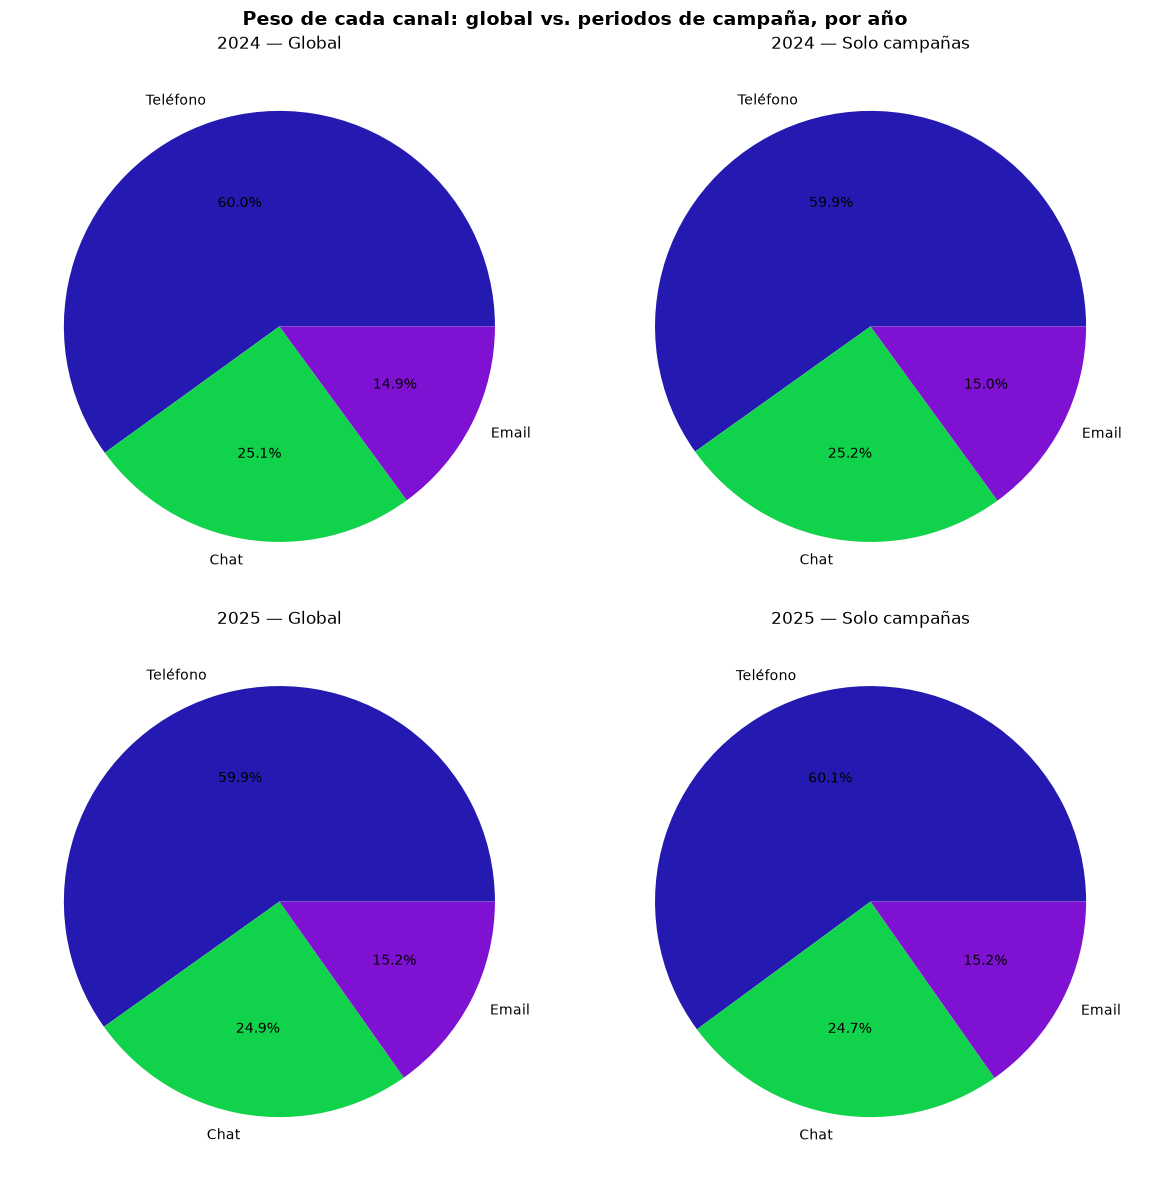

In [17]:
colores = ["#241ab1", "#11d24b", "#7e11d2"]
anios = sorted(df_contactos['anio'].unique())

fig, axes = plt.subplots(len(anios), 2, figsize=(12, 6*len(anios)))

for i, anio in enumerate(anios):
    reparto_global = df_contactos[df_contactos['anio'] == anio]['canal'].value_counts()
    reparto_campania = contactos_campania[contactos_campania['anio'] == anio]['canal'].value_counts()

    axes[i, 0].pie(reparto_global, labels=reparto_global.index, autopct='%1.1f%%', colors=colores)
    axes[i, 0].set_title(f'{anio} — Global')

    axes[i, 1].pie(reparto_campania, labels=reparto_campania.index, autopct='%1.1f%%', colors=colores)
    axes[i, 1].set_title(f'{anio} — Solo campañas')

plt.suptitle('Peso de cada canal: global vs. periodos de campaña, por año', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Volumen total de contactos por hora del día

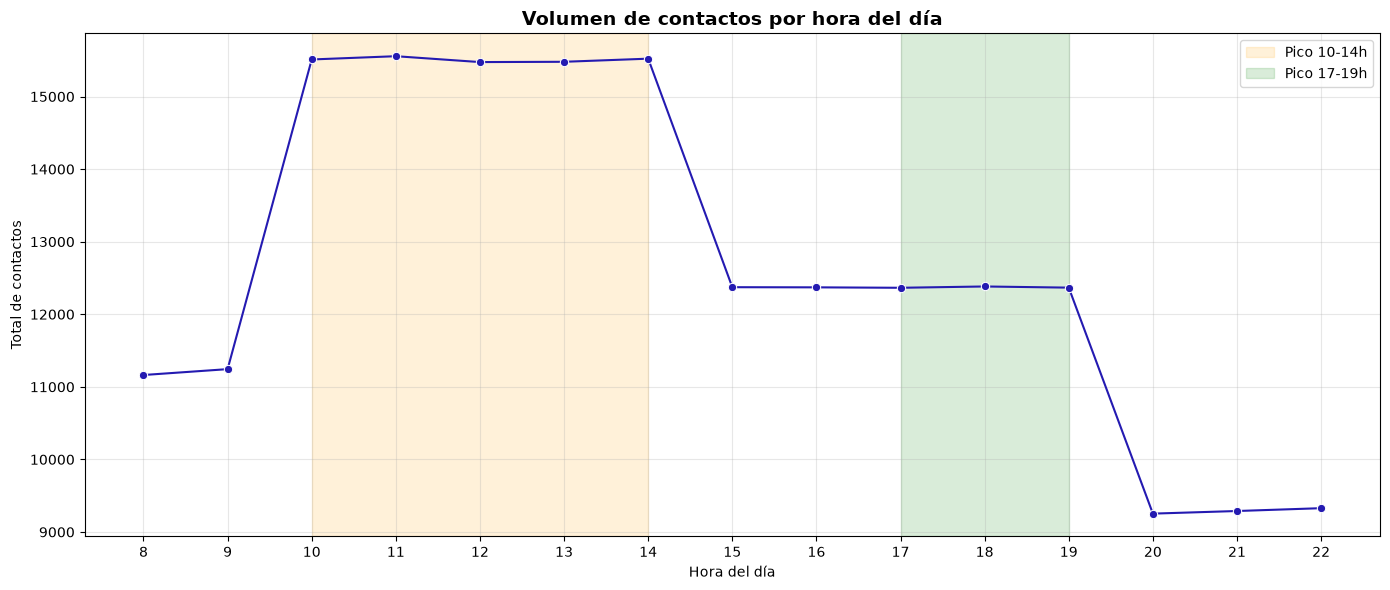

In [18]:
volumen_hora = df_contactos.groupby('hora_inicio').size().reset_index(name='total_contactos')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=volumen_hora,
    x='hora_inicio',
    y='total_contactos',
    marker='o',
    color='#241ab1'
)

# Resaltar las franjas de pico que menciona el contexto de negocio (10-14h y 17-19h)
plt.axvspan(10, 14, color='orange', alpha=0.15, label='Pico 10-14h')
plt.axvspan(17, 19, color='green', alpha=0.15, label='Pico 17-19h')

plt.title('Volumen de contactos por hora del día', fontsize=14, fontweight='bold')
plt.xlabel('Hora del día')
plt.ylabel('Total de contactos')
plt.xticks(range(8, 23))  # el horario de atención es de 08:00 a 22:00
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones — Análisis temporal del volumen

**Evolución mensual global (2024 vs. 2025)**
El volumen mensual sigue un patrón muy similar entre ambos años, con las mismas fases: caída marcada en febrero, una meseta estable entre marzo y octubre, y un repunte fuerte en noviembre-diciembre. La práctica superposición de ambas curvas indica que el negocio tiene una estacionalidad consistente y predecible año a año, sin cambios estructurales relevantes de 2024 a 2025.

**Evolución mensual por departamento**
El patrón mensual se repite de forma consistente en los dos años dentro de cada departamento: ATC muestra el mayor volumen en todos los meses, seguido de Soporte Técnico y Ventas, manteniendo sus posiciones relativas estables. El repunte de noviembre-diciembre se concentra sobre todo en ATC, que es quien más crece en términos absolutos durante campañas.

**Volumen por departamento en periodos de campaña (semana a semana)**
Al aislar las 3 campañas y analizarlas por semana relativa, se observa que ATC no solo tiene mayor volumen base, sino que **crece de forma más pronunciada** a medida que avanza la campaña, especialmente en Black Friday y Navidad (con incrementos visibles entre la primera y última semana). Soporte Técnico y Ventas se mantienen más estables o con crecimientos más moderados durante las mismas campañas. Esto sugiere que el impacto de las campañas comerciales recae de forma desproporcionada sobre ATC, información relevante para reforzar la dotación de ese departamento en fechas concretas.

**Peso de los canales (global vs. campaña, por año)**
La distribución de canales es prácticamente idéntica entre el escenario global y el de solo campañas, tanto en 2024 como en 2025 (Teléfono ~60%, Chat ~25%, Email ~15%, con variaciones de apenas ±0.3 puntos porcentuales). Esto indica que **las campañas comerciales no alteran la mezcla de canales**: el cliente sigue prefiriendo el mismo canal de contacto independientemente de si hay una promoción activa o no. Es un hallazgo relevante porque simplifica la planificación de campaña: no hace falta reforzar canales digitales de forma diferenciada, el refuerzo debe ser proporcional en los tres canales.

**Volumen por hora del día**
El patrón horario confirma casi perfectamente lo descrito en el contexto de negocio: se observan dos picos claros, uno entre las 10:00 y las 14:00 (con el máximo absoluto del día, en torno a 15.500 contactos/hora) y otro, más moderado, entre las 17:00 y las 19:00 (~12.400 contactos/hora). Entre ambos picos hay un descenso notable a las 15:00-16:00, y las horas de apertura (8:00-9:00) y cierre (20:00-22:00) muestran el volumen más bajo del día. Este patrón es consistente con la operativa esperada de un contact center de e-commerce, y valida que el dataset sintético respeta la estacionalidad horaria descrita en el contexto del proyecto.

**Lectura conjunta**
Los datos muestran una operación con estacionalidad muy marcada en tres niveles distintos: mensual (repunte de campañas en Q4), horario (picos de mañana y tarde) y departamental (ATC como principal receptor del crecimiento en campaña). La proporción de canales, en cambio, se mantiene estable en todos los escenarios analizados, lo que sugiere que el comportamiento del cliente en cuanto a "cómo contacta" es independiente del contexto (campaña o no, año), mientras que "cuánto contacta y cuándo" sí varía de forma predecible y aprovechable para el dimensionamiento de personal.

## Correlaciones.

### Volumen de contactos vs. agentes presentes

In [21]:
# Extraer la hora de inicio de la franja como entero, ej. "10:00-11:00" -> 10
df_agentes['hora_inicio'] = (
    df_agentes['franja_horaria']
    .astype(str)
    .str.split('-').str[0]
    .str.split(':').str[0]
    .astype(int)
)

In [22]:
contactos_hora = df_contactos.groupby(['fecha', 'hora_inicio']).size().reset_index(name='total_contactos')

tabla_cruzada = contactos_hora.merge(
    df_agentes[['fecha', 'hora_inicio', 'agentes_presentes']],
    on=['fecha', 'hora_inicio'],
    how='inner'
)

In [23]:
tabla_cruzada['total_contactos'].corr(tabla_cruzada['agentes_presentes'])

np.float64(-0.014082123894037742)

In [26]:
tabla_cruzada['total_contactos'].corr(tabla_cruzada['agentes_presentes'], method='spearman')

np.float64(-0.01792036630786914)

### Volumen de contactos vs. absentismo

In [28]:
tabla_cruzada = contactos_hora.merge(
    df_agentes[['fecha', 'hora_inicio', 'agentes_presentes', 'agentes_programados', 'ausencias']],
    on=['fecha', 'hora_inicio'],
    how='inner'
)

# Correlación directa: volumen vs. número absoluto de ausencias
pearson_absentismo = tabla_cruzada['total_contactos'].corr(tabla_cruzada['ausencias'])
spearman_absentismo = tabla_cruzada['total_contactos'].corr(tabla_cruzada['ausencias'], method='spearman')
print(f'Pearson: {pearson_absentismo:.3f} | Spearman: {spearman_absentismo:.3f}')

Pearson: -0.002 | Spearman: -0.005


### Ratio contactos/agentes vs. SLA

In [29]:
# SLA cumplido agregado por fecha y hora (proporción de contactos con SLA cumplido en esa franja)
sla_hora = df_contactos.groupby(['fecha', 'hora_inicio'])['SLA_cumplido'].mean().reset_index()

# Añadir a la tabla cruzada
tabla_cruzada = tabla_cruzada.merge(sla_hora, on=['fecha', 'hora_inicio'], how='inner')

# Calcular el ratio contactos por agente presente
tabla_cruzada['ratio_contactos_agente'] = tabla_cruzada['total_contactos'] / tabla_cruzada['agentes_presentes']

# Correlación
pearson_ratio_sla = tabla_cruzada['ratio_contactos_agente'].corr(tabla_cruzada['SLA_cumplido'])
spearman_ratio_sla = tabla_cruzada['ratio_contactos_agente'].corr(tabla_cruzada['SLA_cumplido'], method='spearman')
print(f'Pearson: {pearson_ratio_sla:.3f} | Spearman: {spearman_ratio_sla:.3f}')

Pearson: 0.005 | Spearman: -0.007


In [38]:
# Comparar el SLA medio en el 10% de franjas con mayor ratio vs. el 10% con menor ratio
top10 = tabla_cruzada.nlargest(int(len(tabla_cruzada)*0.1), 'ratio_contactos_agente')
bottom10 = tabla_cruzada.nsmallest(int(len(tabla_cruzada)*0.1), 'ratio_contactos_agente')

print('SLA medio en el 10% de franjas con MÁS carga por agente:', top10['SLA_cumplido'].mean())
print('SLA medio en el 10% de franjas con MENOS carga por agente:', bottom10['SLA_cumplido'].mean())

SLA medio en el 10% de franjas con MÁS carga por agente: 0.8993375037216363
SLA medio en el 10% de franjas con MENOS carga por agente: 0.8971634914153163


### Volumen vs. AHT

In [31]:
aht_hora = df_contactos.groupby(['fecha', 'hora_inicio'])['duracion_segundos'].mean().reset_index(name='aht_medio')

tabla_cruzada = tabla_cruzada.merge(aht_hora, on=['fecha', 'hora_inicio'], how='inner')

pearson_vol_aht = tabla_cruzada['total_contactos'].corr(tabla_cruzada['aht_medio'])
spearman_vol_aht = tabla_cruzada['total_contactos'].corr(tabla_cruzada['aht_medio'], method='spearman')
print(f'Volumen vs AHT — Pearson: {pearson_vol_aht:.3f} | Spearman: {spearman_vol_aht:.3f}')

Volumen vs AHT — Pearson: 0.176 | Spearman: 0.123


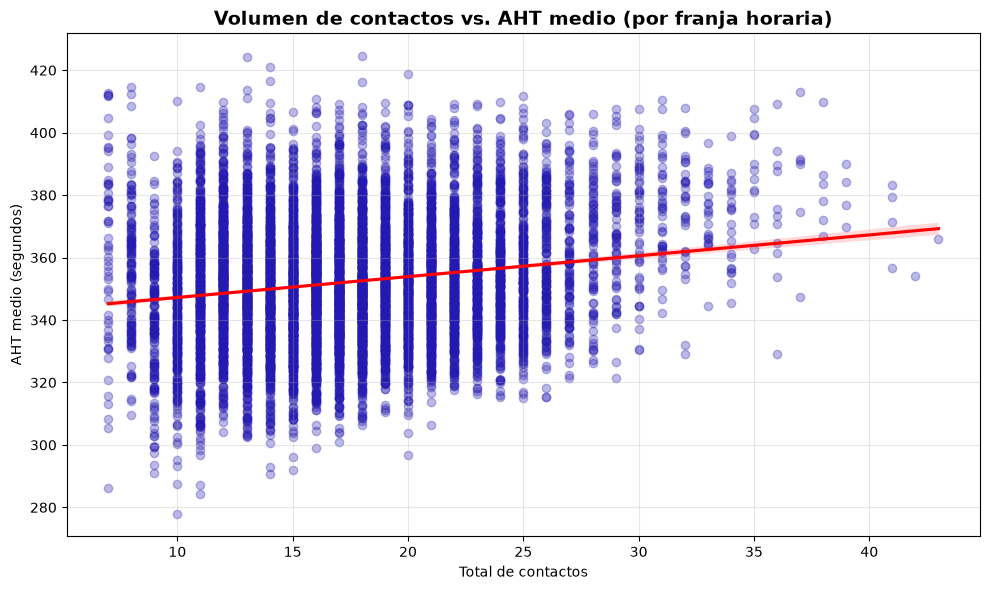

In [33]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=tabla_cruzada,
    x='total_contactos',
    y='aht_medio',
    scatter_kws={'alpha': 0.3, 'color': '#241ab1'},
    line_kws={'color': 'red'}
)
plt.title('Volumen de contactos vs. AHT medio (por franja horaria)', fontsize=14, fontweight='bold')
plt.xlabel('Total de contactos')
plt.ylabel('AHT medio (segundos)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### AHT vs. SLA

In [34]:
pearson_aht_sla = tabla_cruzada['aht_medio'].corr(tabla_cruzada['SLA_cumplido'])
spearman_aht_sla = tabla_cruzada['aht_medio'].corr(tabla_cruzada['SLA_cumplido'], method='spearman')
print(f'AHT vs SLA — Pearson: {pearson_aht_sla:.3f} | Spearman: {spearman_aht_sla:.3f}')

AHT vs SLA — Pearson: 0.001 | Spearman: -0.003


### Volumen de hoy vs. volumen de ayer (misma hora)

In [35]:
# Ordenar es imprescindible para que el "desplazamiento" tenga sentido temporal
contactos_hora_ordenado = contactos_hora.sort_values(['hora_inicio', 'fecha']).copy()

# Por cada hora del día, desplazar el volumen un día hacia atrás
contactos_hora_ordenado['volumen_dia_anterior'] = (
    contactos_hora_ordenado.groupby('hora_inicio')['total_contactos'].shift(1)
)

# Eliminar filas sin valor anterior (el primer día de cada hora no tiene "día anterior")
comparacion_lag = contactos_hora_ordenado.dropna(subset=['volumen_dia_anterior'])

pearson_lag = comparacion_lag['total_contactos'].corr(comparacion_lag['volumen_dia_anterior'])
spearman_lag = comparacion_lag['total_contactos'].corr(comparacion_lag['volumen_dia_anterior'], method='spearman')
print(f'Volumen hoy vs ayer (misma hora) — Pearson: {pearson_lag:.3f} | Spearman: {spearman_lag:.3f}')

Volumen hoy vs ayer (misma hora) — Pearson: 0.640 | Spearman: 0.615


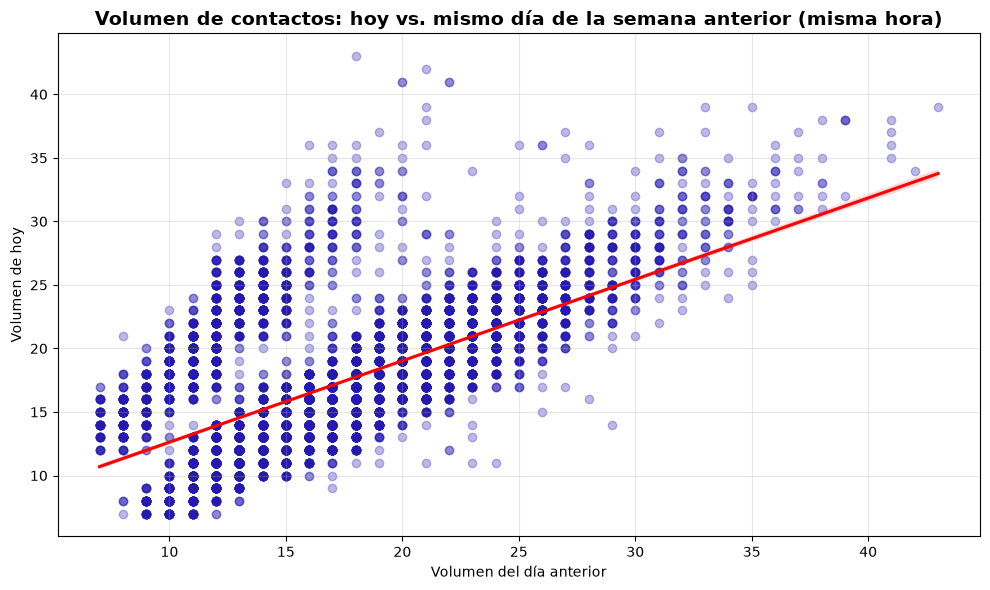

In [36]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=comparacion_lag,
    x='volumen_dia_anterior',
    y='total_contactos',
    scatter_kws={'alpha': 0.3, 'color': '#241ab1'},
    line_kws={'color': 'red'}
)
plt.title('Volumen de contactos: hoy vs. mismo día de la semana anterior (misma hora)', fontsize=14, fontweight='bold')
plt.xlabel('Volumen del día anterior')
plt.ylabel('Volumen de hoy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
df_contactos.groupby('canal')['SLA_cumplido'].mean()

canal
Chat        0.898617
Email       0.899101
Teléfono    0.899729
Name: SLA_cumplido, dtype: float64

## Conclusiones — Correlaciones

Se analizaron seis relaciones entre variables operativas del contact center, cruzando `contactos` y `planificacion` a nivel de fecha y franja horaria (n=10.965).

**Volumen de contactos vs. agentes presentes**
Pearson: -0.014 | Spearman: -0.018

Ambos coeficientes son prácticamente nulos, lo que indica que no existe relación (ni lineal ni monótona) entre el volumen real de contactos y la plantilla presente en esa misma franja. Este resultado es coherente con el funcionamiento esperado de un entorno de WFM: los agentes presentes dependen de una planificación realizada con antelación (basada en una previsión), no de un ajuste reactivo al volumen real de cada hora. Refuerza la relevancia de contar con un modelo predictivo preciso, ya que la calidad de la planificación depende directamente de la calidad del forecast utilizado, no de la capacidad de reacción en tiempo real.

**Volumen de contactos vs. absentismo**
Pearson: -0.002 | Spearman: -0.005

Coeficientes prácticamente nulos. El absentismo no muestra relación con la carga de trabajo esperada; se comporta de forma independiente al contexto operativo.

**Ratio contactos/agente vs. SLA cumplido**
Pearson: 0.005 | Spearman: -0.007

Coeficientes prácticamente nulos. Para descartar una relación no lineal no capturada por estos estadísticos, se comparó el SLA medio entre el 10% de franjas con mayor carga por agente (89.9%) y el 10% con menor carga (89.7%): la diferencia es insignificante. El SLA se comporta de forma prácticamente constante (~90%, coincidiendo con el objetivo de negocio del contexto) e independiente de la carga real de trabajo por agente, en lugar de degradarse cuando el ratio contactos/agente aumenta, como cabría esperar en una operación real.

**AHT vs. SLA cumplido**
Pearson: 0.001 | Spearman: -0.003

Coeficientes prácticamente nulos. Confirma el patrón anterior: el SLA no muestra relación con ninguna de las variables operativas analizadas.

**Volumen de contactos vs. AHT**
Pearson: 0.176 | Spearman: 0.123

Correlación positiva débil. A más volumen de contactos, el AHT tiende a ser ligeramente superior, aunque el efecto es discreto. Que Pearson sea algo mayor que Spearman sugiere que, en la medida en que existe relación, esta es más de tipo lineal que curva.

**Volumen de hoy vs. volumen de ayer (misma hora)**
Pearson: 0.640 | Spearman: 0.615

Correlación moderada-alta y consistente entre ambos métodos. El volumen de contactos muestra una clara autocorrelación día a día a la misma hora: si una franja horaria concreta tiene mucho tráfico un día, es probable que ese mismo tramo horario también lo tenga al día siguiente. Es, con diferencia, la relación más fuerte de todo el bloque.

**Lectura conjunta**

De las seis relaciones analizadas, solo dos muestran una asociación relevante. La más destacable es la autocorrelación del volumen día a día a la misma hora (0.64), que confirma que el histórico reciente es un buen predictor del volumen futuro y la convierte en una **feature candidata de alto valor** para el modelo predictivo (variable lag). La segunda, volumen vs. AHT, muestra una relación positiva pero débil.

El resto de relaciones —volumen vs. agentes presentes, volumen vs. absentismo, ratio contactos/agente vs. SLA, y AHT vs. SLA— resultaron prácticamente nulas. Esto sugiere que, en este dataset sintético, las variables de resultado operativo (SLA, absentismo) fueron generadas de forma en gran medida independiente de la carga real de trabajo, a diferencia de lo que cabría esperar en una operación real. Esta es una limitación relevante a tener en cuenta: si el proyecto se extendiera a predecir SLA o absentismo (no solo volumen), este hallazgo anticipa que no habría relaciones fuertes que explotar con las variables actualmente disponibles.

**Aclaración sobre el rol del SLA en el proyecto**

Aunque el SLA no resulta un buen candidato como variable objetivo del modelo predictivo (no muestra relación explotable con el resto de variables del dataset), sigue siendo relevante como **criterio de éxito del proyecto**: el objetivo final es predecir el volumen de contactos para dimensionar personal de forma que se sostenga el SLA objetivo del 90% marcado por el negocio. El SLA, por tanto, no se modela como output del sistema predictivo, pero sí se mantiene como la métrica con la que evaluar si el dimensionamiento resultante de las predicciones de volumen es adecuado.